<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/08_AngioCAD_%ED%98%91%EC%B0%A9%EB%93%B1%EA%B8%89_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08. AngioCAD 협착 등급 Classifier + Grad-CAM
## 이 노트북이 하는 일
- 입력: 원본 XCA 프레임만 (U-Net / MedicalSAM3 mask 사용 안 함)
- 라벨: Excel 15분절 × 7등급 (NL, 1-25, 26-50, 51-75, 76-90, 91-99, 100)
- 보조 헤드: 해당 view에서 51% 초과 협착 여부
- 백본: ResNet50 ImageNet pretrained (1차). EfficientNet 등은 이후 비교
- Grad-CAM: 분류기가 어디를 봤는지 사후 설명. 병변 GT가 아님
## 고정 규칙
- 03번 환자 split 재사용. 이미지 단위 분할 금지
- DEVELOPMENT 안에서만 학습·early stopping. TEST는 마지막 셀
- 한 series당 중간 프레임 1장 (first/last는 조영 없는 경우가 많음)
- LEFT series는 좌측 10분절만, RIGHT series는 우측 5분절만 loss에 넣음
- 평가 공식은 frame이 아니라 **patient-view 집계**
## 아직 하지 않는 것
- SAM/U-Net mask를 분류 입력으로 넣기
- 중심선·직경으로 협착률 계산
- LISA / mLLM joint training

In [1]:
#@title 01. 마운트, 시드, 경로, 설정

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import math
import random
import hashlib
import shutil
import subprocess
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 30
PATIENCE = 7
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
OVER50_LOSS_WEIGHT = 0.5
VAL_FOLD = 0
FRAMES_PER_SERIES = "middle"  # "middle" | "first_middle_last"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

PREPROCESSING_DIR = PROJECT_ROOT / "preprocessing_results"
SPLIT_DIR = PROJECT_ROOT / "split_results"
LABELS_PATH = PROJECT_ROOT / "AngioCAD_Labels.xlsx"
MANIFEST_PATH = PREPROCESSING_DIR / "03_eligible_frame_manifest.csv"

SPLIT_CANDIDATES = [
    SPLIT_DIR / "02_patient_split_manifest.csv",
    SPLIT_DIR / "01_patient_split_candidate_seed42.csv",
]

RESULT_DIR = (
    PROJECT_ROOT
    / "classifier_results"
    / "08_resnet50_stenosis_grade"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Project:", PROJECT_ROOT)
print("Project exists:", PROJECT_ROOT.exists())
print("Labels:", LABELS_PATH.exists(), LABELS_PATH)
print("Manifest:", MANIFEST_PATH.exists())

for path in SPLIT_CANDIDATES:
    print("Split candidate:", path.name, path.exists())

Mounted at /content/drive
Device: cuda
Project: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
Project exists: True
Labels: True /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/AngioCAD_Labels.xlsx
Manifest: True
Split candidate: 02_patient_split_manifest.csv True
Split candidate: 01_patient_split_candidate_seed42.csv True


In [2]:
#@title 02. 분절·등급 상수

ARTERY_COLUMNS = [
    "LM", "Prox LAD", "Mid LAD", "Dist LAD",
    "1st dig", "2nd dig",
    "Prox LCX", "Mid LCX", "Dist LCX", "OM",
    "Prox RCA", "Mid RCA", "Dist RCA", "PDA", "PLB",
]

LEFT_ARTERY_COLUMNS = ARTERY_COLUMNS[:10]
RIGHT_ARTERY_COLUMNS = ARTERY_COLUMNS[10:]

ALLOWED_LABELS = [
    "NL", "1-25", "26-50", "51-75", "76-90", "91-99", "100",
]

SEVERITY_GRADE = {
    "NL": 0,
    "1-25": 1,
    "26-50": 2,
    "51-75": 3,
    "76-90": 4,
    "91-99": 5,
    "100": 6,
}

GRADE_LABEL = {v: k for k, v in SEVERITY_GRADE.items()}
NUM_GRADES = 7
NUM_ARTERIES = len(ARTERY_COLUMNS)
IGNORE_INDEX = -100
OVER50_THRESHOLD_GRADE = 3  # 51-75 이상

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def normalize_stenosis_label(value):
    if pd.isna(value):
        return "MISSING"

    text = str(value).strip().upper()
    text = (
        text.replace("–", "-")
        .replace("—", "-")
        .replace("−", "-")
        .replace(" ", "")
    )

    if text in {"NORMAL", "NOLESION", "0", "0.0"}:
        return "NL"

    if text.endswith(".0"):
        text = text[:-2]

    return text


def grade_from_value(value):
    label = normalize_stenosis_label(value)
    return SEVERITY_GRADE.get(label, IGNORE_INDEX)


def detect_id_column(df):
    for column in ["patient_id", "ID", "id", "Patient ID"]:
        if column in df.columns:
            return column
    raise KeyError(f"patient ID 열 없음: {list(df.columns)[:20]}")


print("arteries:", NUM_ARTERIES)
print("left:", len(LEFT_ARTERY_COLUMNS), "right:", len(RIGHT_ARTERY_COLUMNS))

arteries: 15
left: 10 right: 5


In [3]:
#@title 03. AngioCAD RAR 해제 또는 기존 경로 재사용

LOCAL_BASE = Path("/content/AngioCAD")
ANGIOCAD_ROOT = LOCAL_BASE / "AngioCAD_Dataset"


def numeric_patient_count(path):
    if not path.is_dir():
        return 0
    return sum(
        1
        for child in path.iterdir()
        if child.is_dir() and child.name.isdigit()
    )


existing_count = numeric_patient_count(ANGIOCAD_ROOT)
print("기존 환자 폴더:", existing_count, ANGIOCAD_ROOT)

if existing_count >= 412:
    print("이미 압축 해제되어 있어 건너뜁니다.")
else:
    RAR_PARTS = [
        PROJECT_ROOT / f"AngioCAD_Dataset.part{part}.rar"
        for part in range(1, 5)
    ]
    RAR_PART1 = RAR_PARTS[0]

    for path in RAR_PARTS:
        print(
            path.name,
            "| exists:", path.exists(),
            "| GB:",
            round(path.stat().st_size / 1024**3, 2) if path.exists() else None,
        )

    assert all(p.exists() for p in RAR_PARTS), "RAR part1~4가 필요합니다."

    if shutil.which("unrar") is None:
        subprocess.run(["apt-get", "update", "-qq"], check=True)
        subprocess.run(["apt-get", "install", "-y", "unrar"], check=True)

    free_gb = shutil.disk_usage("/content").free / 1024**3
    print("/content 여유 GB:", round(free_gb, 2))
    assert free_gb >= 30, "임시 디스크 30GB 미만"

    LOCAL_BASE.mkdir(parents=True, exist_ok=True)

    start = time.time()
    extract_result = subprocess.run(
        ["unrar", "x", "-o+", "-idq", str(RAR_PART1), str(LOCAL_BASE) + "/"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        errors="replace",
    )
    print("unrar code:", extract_result.returncode, "분:", round((time.time() - start) / 60, 2))
    if extract_result.returncode != 0:
        print(extract_result.stdout[-4000:])
    assert extract_result.returncode == 0

    if numeric_patient_count(ANGIOCAD_ROOT) < 412:
        found = [
            p for p in LOCAL_BASE.rglob("AngioCAD_Dataset")
            if p.is_dir() and numeric_patient_count(p) >= 412
        ]
        assert found, "AngioCAD_Dataset를 찾지 못했습니다."
        ANGIOCAD_ROOT = found[0]

print("ANGIOCAD_ROOT:", ANGIOCAD_ROOT)
print("환자 폴더:", numeric_patient_count(ANGIOCAD_ROOT))
assert numeric_patient_count(ANGIOCAD_ROOT) >= 412

기존 환자 폴더: 0 /content/AngioCAD/AngioCAD_Dataset
AngioCAD_Dataset.part1.rar | exists: True | GB: 3.91
AngioCAD_Dataset.part2.rar | exists: True | GB: 3.91
AngioCAD_Dataset.part3.rar | exists: True | GB: 3.91
AngioCAD_Dataset.part4.rar | exists: True | GB: 3.56
/content 여유 GB: 188.38
unrar code: 0 분: 4.39
ANGIOCAD_ROOT: /content/AngioCAD/AngioCAD_Dataset
환자 폴더: 413


In [4]:
#@title 04. split / manifest / labels 로드

split_path = next((p for p in SPLIT_CANDIDATES if p.exists()), None)
assert split_path is not None, "03번 split CSV가 없습니다."
assert MANIFEST_PATH.exists(), "03_eligible_frame_manifest.csv 없음"
assert LABELS_PATH.exists(), "AngioCAD_Labels.xlsx 없음"

split_df = pd.read_csv(split_path)
manifest_df = pd.read_csv(MANIFEST_PATH)
labels_df = pd.read_excel(LABELS_PATH)

for df in [split_df, manifest_df, labels_df]:
    df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]

split_id = detect_id_column(split_df)
labels_id = detect_id_column(labels_df)

split_df["patient_id"] = pd.to_numeric(split_df[split_id], errors="raise").astype(int)
labels_df["patient_id"] = pd.to_numeric(labels_df[labels_id], errors="raise").astype(int)
manifest_df["patient_id"] = pd.to_numeric(manifest_df["patient_id"], errors="raise").astype(int)
manifest_df["series_id"] = pd.to_numeric(manifest_df["series_id"], errors="raise").astype(int)
manifest_df["view"] = manifest_df["view"].astype(str).str.strip().str.upper()

missing_artery = set(ARTERY_COLUMNS) - set(labels_df.columns)
assert not missing_artery, f"라벨 열 누락: {sorted(missing_artery)}"

for column in ARTERY_COLUMNS:
    labels_df[column] = labels_df[column].map(normalize_stenosis_label)

bad = []
for column in ARTERY_COLUMNS:
    unexpected = set(labels_df[column].unique()) - set(ALLOWED_LABELS) - {"MISSING"}
    if unexpected:
        bad.append((column, sorted(unexpected)))
assert not bad, f"허용되지 않은 등급: {bad}"

assert split_df["patient_id"].duplicated().sum() == 0
assert labels_df["patient_id"].duplicated().sum() == 0
assert split_df["final_split"].isin(["DEVELOPMENT", "TEST"]).all()
assert split_df["patient_id"].nunique() == 412, split_df["patient_id"].nunique()

print("split file:", split_path.name)
print("split patients:", split_df["patient_id"].nunique(), split_df["final_split"].value_counts().to_dict())
print("manifest frames:", len(manifest_df), "patients:", manifest_df["patient_id"].nunique())
print("labels patients:", labels_df["patient_id"].nunique())
print("view:", manifest_df["view"].value_counts().to_dict())
print("✅ 표 Gate 통과")

split file: 02_patient_split_manifest.csv
split patients: 412 {'DEVELOPMENT': 329, 'TEST': 83}
manifest frames: 119046 patients: 412
labels patients: 413
view: {'LEFT': 81476, 'RIGHT': 37570}
✅ 표 Gate 통과


/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [5]:
#@title 05. series 중간 프레임 + view별 분절 라벨

work = manifest_df.copy()
work = work[work["view"].isin(["LEFT", "RIGHT"])].copy()

if "paper_eligible" in work.columns:
    before = len(work)
    work = work[work["paper_eligible"] == True].copy()
    print("paper_eligible 필터:", before, "->", len(work))

split_keep = ["patient_id", "final_split"]
if "development_cv_fold" in split_df.columns:
    split_keep.append("development_cv_fold")

work = work.merge(
    split_df[split_keep],
    on="patient_id",
    how="inner",
    validate="many_to_one",
)

work = work.merge(
    labels_df[["patient_id"] + ARTERY_COLUMNS],
    on="patient_id",
    how="inner",
    validate="many_to_one",
)

work["_frame_order"] = (
    work["frame_name"].astype(str).str.extract(r"(\d+)")[0].astype(int)
)


def pick_frames(group_df):
    group_df = group_df.sort_values("_frame_order").reset_index(drop=True)
    n = len(group_df)
    if FRAMES_PER_SERIES == "middle":
        idx = [n // 2]
        names = ["MIDDLE"]
    else:
        idx = sorted(set([0, n // 2, n - 1]))
        names = []
        for i in idx:
            if i == 0:
                names.append("FIRST")
            elif i == n - 1:
                names.append("LAST")
            else:
                names.append("MIDDLE")
    out = group_df.iloc[idx].copy()
    out["sample_position"] = names
    return out


picked = [
    pick_frames(g)
    for _, g in work.groupby(["patient_id", "series_id"], sort=True)
]
frame_df = pd.concat(picked, ignore_index=True)
frame_df = frame_df.drop(columns=["_frame_order"])

frame_df["resolved_frame_path"] = [
    str(
        ANGIOCAD_ROOT
        / str(int(pid))
        / str(int(sid))
        / str(name)
    )
    for pid, sid, name in zip(
        frame_df["patient_id"],
        frame_df["series_id"],
        frame_df["frame_name"],
    )
]

exists_mask = [Path(p).is_file() for p in frame_df["resolved_frame_path"]]
print("고른 프레임:", len(frame_df), "존재:", sum(exists_mask))
assert np.mean(exists_mask) > 0.95, "이미지 경로 실패가 많습니다. ANGIOCAD_ROOT 확인"
frame_df = frame_df.loc[exists_mask].reset_index(drop=True)

grade_matrix = np.full((len(frame_df), NUM_ARTERIES), IGNORE_INDEX, dtype=np.int64)
visible_matrix = np.zeros((len(frame_df), NUM_ARTERIES), dtype=np.int64)
over50 = np.zeros(len(frame_df), dtype=np.float32)

for i, row in frame_df.iterrows():
    visible_cols = (
        LEFT_ARTERY_COLUMNS if row["view"] == "LEFT" else RIGHT_ARTERY_COLUMNS
    )
    visible_grades = []
    for j, artery in enumerate(ARTERY_COLUMNS):
        if artery not in visible_cols:
            continue
        g = grade_from_value(row[artery])
        if g == IGNORE_INDEX:
            continue
        grade_matrix[i, j] = g
        visible_matrix[i, j] = 1
        visible_grades.append(g)
    if visible_grades:
        over50[i] = float(max(visible_grades) >= OVER50_THRESHOLD_GRADE)

frame_df["over50"] = over50
frame_df["n_visible"] = visible_matrix.sum(axis=1)

assert (frame_df["n_visible"] > 0).all()
print(frame_df.groupby(["final_split", "view"]).size())
print("over50 rate:", float(frame_df["over50"].mean()))
print("✅ 프레임 표 생성")

paper_eligible 필터: 119046 -> 119020
고른 프레임: 2676 존재: 2676
final_split  view 
DEVELOPMENT  LEFT     1503
             RIGHT     657
TEST         LEFT      360
             RIGHT     156
dtype: int64
over50 rate: 0.6382660865783691
✅ 프레임 표 생성


In [6]:
#@title 06. DEVELOPMENT fold 분할, TEST 잠금

dev_mask = frame_df["final_split"].eq("DEVELOPMENT")
test_mask = frame_df["final_split"].eq("TEST")

if "development_cv_fold" in frame_df.columns:
    val_mask = dev_mask & frame_df["development_cv_fold"].eq(VAL_FOLD)
    train_mask = dev_mask & ~frame_df["development_cv_fold"].eq(VAL_FOLD)
else:
    rng = np.random.RandomState(SEED)
    dev_patients = frame_df.loc[dev_mask, "patient_id"].unique()
    rng.shuffle(dev_patients)
    n_val = max(1, int(round(0.2 * len(dev_patients))))
    val_patients = set(dev_patients[:n_val])
    val_mask = dev_mask & frame_df["patient_id"].isin(val_patients)
    train_mask = dev_mask & ~frame_df["patient_id"].isin(val_patients)

train_idx = np.where(train_mask.to_numpy())[0]
val_idx = np.where(val_mask.to_numpy())[0]
test_idx = np.where(test_mask.to_numpy())[0]

train_patients = set(frame_df.iloc[train_idx]["patient_id"])
val_patients = set(frame_df.iloc[val_idx]["patient_id"])
test_patients = set(frame_df.iloc[test_idx]["patient_id"])

assert not (train_patients & val_patients)
assert not (train_patients & test_patients)
assert not (val_patients & test_patients)

print("TRAIN frames/patients:", len(train_idx), len(train_patients))
print("VAL   frames/patients:", len(val_idx), len(val_patients))
print("TEST  frames/patients:", len(test_idx), len(test_patients), "(잠금)")

visible_train_grades = grade_matrix[train_idx][visible_matrix[train_idx] == 1]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_GRADES),
    y=visible_train_grades,
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("grade class weights:", np.round(class_weights, 3))

pos = frame_df.iloc[train_idx]["over50"].sum()
neg = len(train_idx) - pos
over50_pos_weight = torch.tensor([neg / max(pos, 1.0)], device=DEVICE)
print("over50 pos_weight:", float(over50_pos_weight))

TRAIN frames/patients: 1747 263
VAL   frames/patients: 413 66
TEST  frames/patients: 516 83 (잠금)
grade class weights: [0.196 2.868 2.479 3.915 2.299 3.167 6.591]
over50 pos_weight: 0.5668161511421204


In [7]:
#@title 07. Dataset, ResNet50, loss

from torchvision.models import resnet50, ResNet50_Weights


def load_xca_tensor(path, train=False):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    assert image is not None, path

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

    if train:
        if random.random() < 0.5:
            image = np.fliplr(image).copy()
        angle = random.uniform(-10, 10)
        matrix = cv2.getRotationMatrix2D(
            (IMAGE_SIZE / 2, IMAGE_SIZE / 2), angle, 1.0
        )
        image = cv2.warpAffine(
            image, matrix, (IMAGE_SIZE, IMAGE_SIZE),
            flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101,
        )

    image = image.astype(np.float32) / 255.0
    image = np.repeat(image[..., None], 3, axis=2)
    image = (image - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
    tensor = torch.from_numpy(image).permute(2, 0, 1).float()
    return tensor


class StenosisFrameDataset(Dataset):
    def __init__(self, indices, train=False):
        self.indices = list(indices)
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        i = self.indices[item]
        row = frame_df.iloc[i]
        image = load_xca_tensor(row["resolved_frame_path"], train=self.train)
        return {
            "image": image,
            "grades": torch.from_numpy(grade_matrix[i]).long(),
            "visible": torch.from_numpy(visible_matrix[i]).float(),
            "over50": torch.tensor(row["over50"], dtype=torch.float32),
            "patient_id": int(row["patient_id"]),
            "view": row["view"],
            "index": i,
        }


class StenosisResNet50(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        self.backbone = resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.artery_head = nn.Linear(in_features, NUM_ARTERIES * NUM_GRADES)
        self.over50_head = nn.Linear(in_features, 1)

    def forward(self, x):
        feat = self.backbone(x)
        artery_logits = self.artery_head(feat).view(-1, NUM_ARTERIES, NUM_GRADES)
        over50_logits = self.over50_head(feat).squeeze(1)
        return artery_logits, over50_logits, feat

    def last_conv(self):
        return self.backbone.layer4


def compute_loss(artery_logits, over50_logits, grades, over50_target):
    b, a, c = artery_logits.shape
    ce = F.cross_entropy(
        artery_logits.reshape(b * a, c),
        grades.reshape(b * a),
        weight=class_weights_t,
        ignore_index=IGNORE_INDEX,
    )
    bce = F.binary_cross_entropy_with_logits(
        over50_logits,
        over50_target,
        pos_weight=over50_pos_weight,
    )
    total = ce + OVER50_LOSS_WEIGHT * bce
    return total, ce.detach(), bce.detach()


train_ds = StenosisFrameDataset(train_idx, train=True)
val_ds = StenosisFrameDataset(val_idx, train=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

batch = next(iter(train_loader))
print("image:", tuple(batch["image"].shape), "grades:", tuple(batch["grades"].shape))
assert batch["image"].shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
print("✅ Dataset Gate")

image: (32, 3, 224, 224) grades: (32, 15)
✅ Dataset Gate


In [8]:
#@title 08. tiny overfit smoke test

smoke_model = StenosisResNet50().to(DEVICE)
smoke_opt = torch.optim.AdamW(smoke_model.parameters(), lr=1e-3)
smoke_n = min(8, len(train_ds))
smoke_loader = DataLoader(
    torch.utils.data.Subset(train_ds, list(range(smoke_n))),
    batch_size=smoke_n,
    shuffle=False,
)
smoke_batch = next(iter(smoke_loader))
images = smoke_batch["image"].to(DEVICE)
grades = smoke_batch["grades"].to(DEVICE)
y50 = smoke_batch["over50"].to(DEVICE)

smoke_model.train()
losses = []
for step in range(40):
    smoke_opt.zero_grad(set_to_none=True)
    a_log, o_log, _ = smoke_model(images)
    loss, ce, bce = compute_loss(a_log, o_log, grades, y50)
    loss.backward()
    smoke_opt.step()
    losses.append(float(loss))

print("tiny start:", round(losses[0], 4), "end:", round(losses[-1], 4))
assert losses[-1] < losses[0] * 0.7, "tiny overfit 실패. 라벨/loss를 확인하세요."
print("✅ tiny overfit 통과")

del smoke_model, smoke_opt
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]
/tmp/ipykernel_1102/2199187207.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(loss))


tiny start: 2.1226 end: 0.0
✅ tiny overfit 통과


In [9]:
#@title 09. ResNet50 학습. TEST 보지 않음

model = StenosisResNet50().to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())


@torch.no_grad()
def evaluate(loader):
    model.eval()
    recs = []
    tot = ce_sum = bce_sum = n = 0.0
    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        grades = batch["grades"].to(DEVICE, non_blocking=True)
        y50 = batch["over50"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            a_log, o_log, _ = model(images)
            loss, ce, bce = compute_loss(a_log, o_log, grades, y50)
        tot += float(loss) * images.size(0)
        ce_sum += float(ce) * images.size(0)
        bce_sum += float(bce) * images.size(0)
        n += images.size(0)

        a_prob = torch.softmax(a_log, dim=-1).cpu().numpy()
        o_prob = torch.sigmoid(o_log).cpu().numpy()
        grades_np = batch["grades"].numpy()
        visible_np = batch["visible"].numpy()
        for k in range(images.size(0)):
            recs.append({
                "patient_id": int(batch["patient_id"][k]),
                "view": batch["view"][k],
                "over50_true": float(batch["over50"][k]),
                "over50_prob": float(o_prob[k]),
                "grade_true": grades_np[k],
                "grade_prob": a_prob[k],
                "visible": visible_np[k],
            })
    return {
        "loss": tot / max(n, 1),
        "ce": ce_sum / max(n, 1),
        "bce": bce_sum / max(n, 1),
        "records": recs,
    }


def patient_view_metrics(records, split_name):
    rows = []
    for rec in records:
        pred_grade = rec["grade_prob"].argmax(axis=1)
        for j, artery in enumerate(ARTERY_COLUMNS):
            if rec["visible"][j] < 0.5:
                continue
            rows.append({
                "patient_id": rec["patient_id"],
                "view": rec["view"],
                "artery": artery,
                "true": int(rec["grade_true"][j]),
                "pred": int(pred_grade[j]),
                "prob_over50_artery": float(rec["grade_prob"][j, OVER50_THRESHOLD_GRADE:].sum()),
                "over50_true": rec["over50_true"],
                "over50_prob": rec["over50_prob"],
            })
    df = pd.DataFrame(rows)
    # 같은 환자-view-동맥이 여러 series면 확률 평균
    agg = (
        df.groupby(["patient_id", "view", "artery"], as_index=False)
        .agg(
            true=("true", "first"),
            pred=("pred", lambda s: int(s.mode().iloc[0])),
            prob_over50_artery=("prob_over50_artery", "mean"),
            over50_true=("over50_true", "first"),
            over50_prob=("over50_prob", "mean"),
        )
    )
    y_true = agg["true"].to_numpy()
    y_pred = agg["pred"].to_numpy()
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    bacc = balanced_accuracy_score(y_true, y_pred)
    view_df = (
        agg.groupby(["patient_id", "view"], as_index=False)
        .agg(over50_true=("over50_true", "first"), over50_prob=("over50_prob", "mean"))
    )
    try:
        auroc = roc_auc_score(view_df["over50_true"], view_df["over50_prob"])
        auprc = average_precision_score(view_df["over50_true"], view_df["over50_prob"])
    except ValueError:
        auroc = auprc = float("nan")

    binary_true = (y_true >= OVER50_THRESHOLD_GRADE).astype(int)
    try:
        artery_auroc = roc_auc_score(binary_true, agg["prob_over50_artery"])
    except ValueError:
        artery_auroc = float("nan")

    metrics = {
        "split": split_name,
        "n_patient_view_artery": int(len(agg)),
        "n_patient_view": int(len(view_df)),
        "grade_qwk": float(qwk),
        "grade_balanced_acc": float(bacc),
        "view_over50_auroc": float(auroc),
        "view_over50_auprc": float(auprc),
        "artery_over50_auroc": float(artery_auroc),
    }
    return metrics, agg, view_df


best_score = -1e9
best_path = RESULT_DIR / "best_resnet50.pt"
history = []
bad_epochs = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running = 0.0
    seen = 0
    for batch in train_loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        grades = batch["grades"].to(DEVICE, non_blocking=True)
        y50 = batch["over50"].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            a_log, o_log, _ = model(images)
            loss, _, _ = compute_loss(a_log, o_log, grades, y50)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += float(loss) * images.size(0)
        seen += images.size(0)

    val_out = evaluate(val_loader)
    val_metrics, _, _ = patient_view_metrics(val_out["records"], "VAL")
    score = val_metrics["grade_qwk"] + 0.3 * (
        0.0 if math.isnan(val_metrics["view_over50_auroc"])
        else val_metrics["view_over50_auroc"]
    )
    row = {
        "epoch": epoch,
        "train_loss": running / max(seen, 1),
        "val_loss": val_out["loss"],
        **val_metrics,
        "score": score,
    }
    history.append(row)
    print(
        f"epoch {epoch:02d}  train {row['train_loss']:.4f}  "
        f"val {row['val_loss']:.4f}  QWK {row['grade_qwk']:.3f}  "
        f"bAcc {row['grade_balanced_acc']:.3f}  "
        f"over50 AUC {row['view_over50_auroc']:.3f}"
    )

    if score > best_score + 1e-4:
        best_score = score
        bad_epochs = 0
        torch.save(
            {
                "model": model.state_dict(),
                "epoch": epoch,
                "val_metrics": val_metrics,
                "config": {
                    "seed": SEED,
                    "image_size": IMAGE_SIZE,
                    "frames_per_series": FRAMES_PER_SERIES,
                    "val_fold": VAL_FOLD,
                },
            },
            best_path,
        )
        print("  saved", best_path)
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("early stop")
            break

hist_df = pd.DataFrame(history)
hist_df.to_csv(RESULT_DIR / "00_train_history.csv", index=False)
print("best score:", best_score, "path:", best_path)

epoch 01  train 2.1019  val 2.0998  QWK 0.226  bAcc 0.211  over50 AUC 0.747
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08_resnet50_stenosis_grade/best_resnet50.pt
epoch 02  train 1.9706  val 2.0894  QWK 0.252  bAcc 0.210  over50 AUC 0.785
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08_resnet50_stenosis_grade/best_resnet50.pt
epoch 03  train 1.8577  val 2.0902  QWK 0.268  bAcc 0.222  over50 AUC 0.777
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08_resnet50_stenosis_grade/best_resnet50.pt
epoch 04  train 1.7175  val 2.1260  QWK 0.326  bAcc 0.254  over50 AUC 0.787
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08_resnet50_stenosis_grade/best_resnet50.pt
epoch 05  train 1.5606  val 2.1646  QWK 0.323  bAcc 0.257  over50 AUC 0.780
epoch 06  train 1.3928  val 2.1615  QWK 0.324  bAcc 0.257  over50 AUC 0.776
epoch 07  train 1.2053  val 2.34

{
  "split": "VAL",
  "n_patient_view_artery": 980,
  "n_patient_view": 131,
  "grade_qwk": 0.35270633566590925,
  "grade_balanced_acc": 0.27311212471582846,
  "view_over50_auroc": 0.8191438191438191,
  "view_over50_auprc": 0.8155635904018483,
  "artery_over50_auroc": 0.7692917613049762
}

분절별 QWK
1st dig     n=  65  QWK=0.183  bAcc=0.194
2nd dig     n=  65  QWK=-0.018  bAcc=0.196
Dist LAD    n=  65  QWK=0.000  bAcc=0.250
Dist LCX    n=  65  QWK=-0.029  bAcc=0.322
Dist RCA    n=  66  QWK=0.160  bAcc=0.147
LM          n=  65  QWK=0.000  bAcc=0.333
Mid LAD     n=  65  QWK=0.240  bAcc=0.236
Mid LCX     n=  65  QWK=0.186  bAcc=0.157
Mid RCA     n=  66  QWK=0.165  bAcc=0.288
OM          n=  65  QWK=0.394  bAcc=0.211
PDA         n=  66  QWK=0.004  bAcc=0.331
PLB         n=  66  QWK=0.163  bAcc=0.250
Prox LAD    n=  65  QWK=0.078  bAcc=0.364
Prox LCX    n=  65  QWK=0.096  bAcc=0.125
Prox RCA    n=  66  QWK=0.360  bAcc=0.179


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


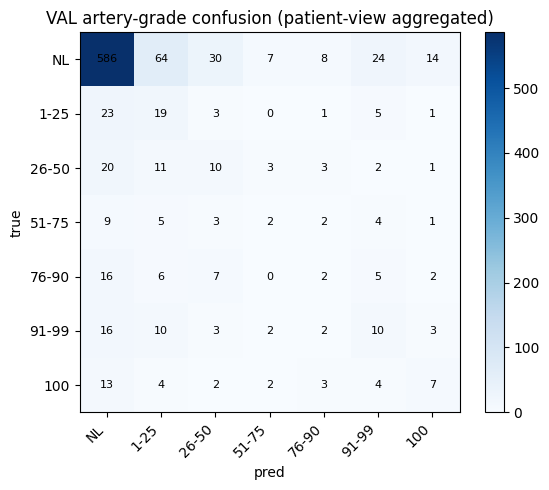

저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08_resnet50_stenosis_grade


In [10]:
#@title 10. best checkpoint VAL 평가

ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
val_out = evaluate(val_loader)
val_metrics, val_agg, val_view = patient_view_metrics(val_out["records"], "VAL")

print(json.dumps(val_metrics, indent=2, ensure_ascii=False))
print("\n분절별 QWK")
for artery, sub in val_agg.groupby("artery"):
    if sub["true"].nunique() < 2:
        continue
    print(
        f"{artery:10s}  n={len(sub):4d}  "
        f"QWK={cohen_kappa_score(sub['true'], sub['pred'], weights='quadratic'):.3f}  "
        f"bAcc={balanced_accuracy_score(sub['true'], sub['pred']):.3f}"
    )

cm = confusion_matrix(val_agg["true"], val_agg["pred"], labels=list(range(NUM_GRADES)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_GRADES), ALLOWED_LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_GRADES), ALLOWED_LABELS)
ax.set_xlabel("pred")
ax.set_ylabel("true")
ax.set_title("VAL artery-grade confusion (patient-view aggregated)")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(RESULT_DIR / "01_val_confusion.png", dpi=150)
plt.show()

val_agg.to_csv(RESULT_DIR / "02_val_patient_view_artery.csv", index=False)
val_view.to_csv(RESULT_DIR / "03_val_patient_view_over50.csv", index=False)
with open(RESULT_DIR / "04_val_metrics.json", "w") as f:
    json.dump(val_metrics, f, indent=2, ensure_ascii=False)
print("저장:", RESULT_DIR)

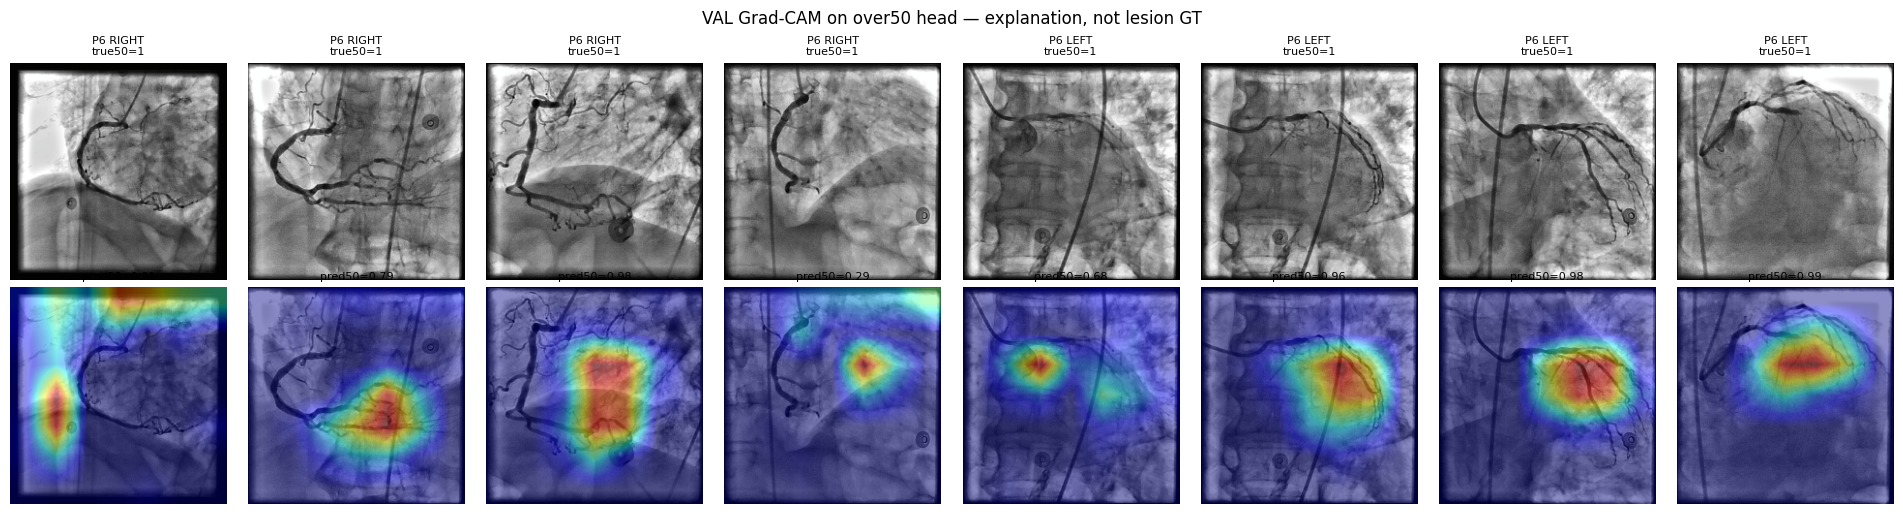

✅ Grad-CAM 저장


In [11]:
#@title 11. Grad-CAM. 병변 GT가 아님

def gradcam_over50(model, image_bchw):
    model.eval()
    activations = []
    gradients = []

    def fwd_hook(_m, _i, output):
        activations.append(output)

    def bwd_hook(_m, _gi, go):
        gradients.append(go[0])

    handle_f = model.last_conv().register_forward_hook(fwd_hook)
    handle_b = model.last_conv().register_full_backward_hook(bwd_hook)

    model.zero_grad(set_to_none=True)
    a_log, o_log, _ = model(image_bchw)
    o_log.sum().backward()

    act = activations[0][0].detach()
    grad = gradients[0][0].detach()
    weights = grad.mean(dim=(1, 2))
    cam = torch.relu((weights[:, None, None] * act).sum(0))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(
        cam[None, None],
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    )[0, 0].cpu().numpy()

    handle_f.remove()
    handle_b.remove()
    pred50 = float(torch.sigmoid(o_log)[0].detach().cpu())
    return cam, pred50


def denorm(t):
    x = t.detach().cpu().permute(1, 2, 0).numpy()
    x = x * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)


n_show = min(8, len(val_ds))
fig, axes = plt.subplots(2, n_show, figsize=(2.4 * n_show, 5.2))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)

for k in range(n_show):
    sample = val_ds[k]
    image = sample["image"][None].to(DEVICE)
    cam, pred50 = gradcam_over50(model, image)
    rgb = denorm(sample["image"])
    row = frame_df.iloc[sample["index"]]

    axes[0, k].imshow(rgb)
    axes[0, k].axis("off")
    axes[0, k].set_title(
        f"P{int(row['patient_id'])} {row['view']}\ntrue50={int(sample['over50'])}",
        fontsize=8,
    )
    axes[1, k].imshow(rgb)
    axes[1, k].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, k].axis("off")
    axes[1, k].set_title(f"pred50={pred50:.2f}", fontsize=8)

fig.suptitle("VAL Grad-CAM on over50 head — explanation, not lesion GT")
fig.tight_layout()
fig.savefig(RESULT_DIR / "05_val_gradcam_over50.png", dpi=150)
plt.show()
print("✅ Grad-CAM 저장")

In [ ]:
#@title 12. TEST 최종 평가. 모델 확정 후에만 실행

assert best_path.exists(), "best checkpoint 없음"
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])

test_ds = StenosisFrameDataset(test_idx, train=False)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

test_out = evaluate(test_loader)
test_metrics, test_agg, test_view = patient_view_metrics(test_out["records"], "TEST")
print(json.dumps(test_metrics, indent=2, ensure_ascii=False))

test_agg.to_csv(RESULT_DIR / "06_test_patient_view_artery.csv", index=False)
test_view.to_csv(RESULT_DIR / "07_test_patient_view_over50.csv", index=False)
with open(RESULT_DIR / "08_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2, ensure_ascii=False)

decision = {
    "notebook": "08_AngioCAD_협착등급_Classifier",
    "backbone": "resnet50",
    "input": "raw XCA middle frame, no SAM/UNet mask",
    "split": "03 patient_split_v1_seed42, val=development_cv_fold 0",
    "val": val_metrics,
    "test": test_metrics,
    "note": "Grad-CAM is post-hoc and is not stenosis localization GT.",
}
with open(RESULT_DIR / "09_final_decision.json", "w") as f:
    json.dump(decision, f, indent=2, ensure_ascii=False)
print("완료. Drive:", RESULT_DIR)

In [12]:
#@title 13. 7등급 포기, 3-bin + over50 재학습. TEST 금지

import math
import random
from collections import defaultdict

NUM_BINS = 3
BIN_NAMES = ["NL", "1-50", "51-100"]
BACKBONE_FREEZE_EPOCHS = 3
MAX_EPOCHS_V2 = 25
PATIENCE_V2 = 6
DROPOUT_P = 0.5
LR_HEAD = 1e-3
LR_BACKBONE = 3e-5
WEIGHT_DECAY_V2 = 1e-3

RESULT_DIR_V2 = (
    PROJECT_ROOT
    / "classifier_results"
    / "08b_resnet50_3bin_over50"
)
RESULT_DIR_V2.mkdir(parents=True, exist_ok=True)


def to_bin(grade):
    if grade == IGNORE_INDEX:
        return IGNORE_INDEX
    if grade == 0:
        return 0
    if grade in (1, 2):
        return 1
    return 2


bin_matrix = np.full_like(grade_matrix, IGNORE_INDEX)
for i in range(len(grade_matrix)):
    for j in range(NUM_ARTERIES):
        bin_matrix[i, j] = to_bin(int(grade_matrix[i, j]))

train_bins = bin_matrix[train_idx][visible_matrix[train_idx] == 1]
print("3-bin train counts:", dict(zip(*np.unique(train_bins, return_counts=True))))

bin_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_BINS),
    y=train_bins,
)
bin_weights_t = torch.tensor(bin_weights, dtype=torch.float32, device=DEVICE)
print("3-bin weights:", np.round(bin_weights, 3))


class StenosisFrameDatasetV2(Dataset):
    def __init__(self, indices, train=False):
        self.indices = list(indices)
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        i = self.indices[item]
        row = frame_df.iloc[i]
        image = load_xca_tensor(row["resolved_frame_path"], train=self.train)
        return {
            "image": image,
            "bins": torch.from_numpy(bin_matrix[i]).long(),
            "visible": torch.from_numpy(visible_matrix[i]).float(),
            "over50": torch.tensor(row["over50"], dtype=torch.float32),
            "patient_id": int(row["patient_id"]),
            "view": row["view"],
            "index": i,
        }


class StenosisResNet50V2(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        self.backbone = resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.dropout = nn.Dropout(DROPOUT_P)
        self.bin_head = nn.Linear(in_features, NUM_ARTERIES * NUM_BINS)
        self.over50_head = nn.Linear(in_features, 1)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.dropout(feat)
        bin_logits = self.bin_head(feat).view(-1, NUM_ARTERIES, NUM_BINS)
        over50_logits = self.over50_head(feat).squeeze(1)
        return bin_logits, over50_logits

    def last_conv(self):
        return self.backbone.layer4

    def set_backbone_trainable(self, trainable):
        for p in self.backbone.parameters():
            p.requires_grad = trainable


def compute_loss_v2(bin_logits, over50_logits, bins, over50_target):
    b, a, c = bin_logits.shape
    ce = F.cross_entropy(
        bin_logits.reshape(b * a, c),
        bins.reshape(b * a),
        weight=bin_weights_t,
        ignore_index=IGNORE_INDEX,
    )
    bce = F.binary_cross_entropy_with_logits(
        over50_logits,
        over50_target,
        pos_weight=over50_pos_weight,
    )
    total = ce + OVER50_LOSS_WEIGHT * bce
    return total, ce.detach(), bce.detach()


train_ds_v2 = StenosisFrameDatasetV2(train_idx, train=True)
val_ds_v2 = StenosisFrameDatasetV2(val_idx, train=False)
train_loader_v2 = DataLoader(
    train_ds_v2, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader_v2 = DataLoader(
    val_ds_v2, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

model_v2 = StenosisResNet50V2().to(DEVICE)
model_v2.set_backbone_trainable(False)

optimizer_v2 = torch.optim.AdamW(
    [
        {"params": [p for p in model_v2.backbone.parameters() if p.requires_grad], "lr": LR_BACKBONE},
        {"params": list(model_v2.bin_head.parameters()) + list(model_v2.over50_head.parameters()) + list(model_v2.dropout.parameters()), "lr": LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY_V2,
)
scaler_v2 = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())


def rebuild_optimizer(trainable_backbone):
    model_v2.set_backbone_trainable(trainable_backbone)
    return torch.optim.AdamW(
        [
            {"params": model_v2.backbone.parameters(), "lr": LR_BACKBONE},
            {
                "params": list(model_v2.bin_head.parameters())
                + list(model_v2.over50_head.parameters()),
                "lr": LR_HEAD,
            },
        ],
        weight_decay=WEIGHT_DECAY_V2,
    )


@torch.no_grad()
def evaluate_v2(loader):
    model_v2.eval()
    recs = []
    tot = n = 0.0
    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        bins = batch["bins"].to(DEVICE, non_blocking=True)
        y50 = batch["over50"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            b_log, o_log = model_v2(images)
            loss, _, _ = compute_loss_v2(b_log, o_log, bins, y50)
        tot += float(loss) * images.size(0)
        n += images.size(0)
        b_prob = torch.softmax(b_log, dim=-1).cpu().numpy()
        o_prob = torch.sigmoid(o_log).cpu().numpy()
        bins_np = batch["bins"].numpy()
        vis_np = batch["visible"].numpy()
        for k in range(images.size(0)):
            recs.append({
                "patient_id": int(batch["patient_id"][k]),
                "view": batch["view"][k],
                "over50_true": float(batch["over50"][k]),
                "over50_prob": float(o_prob[k]),
                "bin_true": bins_np[k],
                "bin_prob": b_prob[k],
                "visible": vis_np[k],
            })
    return tot / max(n, 1), recs


def metrics_v2(records, split_name):
    rows = []
    for rec in records:
        pred = rec["bin_prob"].argmax(axis=1)
        for j, artery in enumerate(ARTERY_COLUMNS):
            if rec["visible"][j] < 0.5:
                continue
            rows.append({
                "patient_id": rec["patient_id"],
                "view": rec["view"],
                "artery": artery,
                "true": int(rec["bin_true"][j]),
                "pred": int(pred[j]),
                "over50_true": rec["over50_true"],
                "over50_prob": rec["over50_prob"],
            })
    df = pd.DataFrame(rows)
    agg = (
        df.groupby(["patient_id", "view", "artery"], as_index=False)
        .agg(
            true=("true", "first"),
            pred=("pred", lambda s: int(s.mode().iloc[0])),
            over50_true=("over50_true", "first"),
            over50_prob=("over50_prob", "mean"),
        )
    )
    view_df = (
        agg.groupby(["patient_id", "view"], as_index=False)
        .agg(over50_true=("over50_true", "first"), over50_prob=("over50_prob", "mean"))
    )
    qwk = cohen_kappa_score(agg["true"], agg["pred"], weights="quadratic")
    bacc = balanced_accuracy_score(agg["true"], agg["pred"])
    try:
        auroc = roc_auc_score(view_df["over50_true"], view_df["over50_prob"])
        auprc = average_precision_score(view_df["over50_true"], view_df["over50_prob"])
    except ValueError:
        auroc = auprc = float("nan")
    return {
        "split": split_name,
        "n_patient_view_artery": int(len(agg)),
        "n_patient_view": int(len(view_df)),
        "bin_qwk": float(qwk),
        "bin_balanced_acc": float(bacc),
        "view_over50_auroc": float(auroc),
        "view_over50_auprc": float(auprc),
    }, agg, view_df


best_score = -1e9
best_path_v2 = RESULT_DIR_V2 / "best_resnet50_3bin.pt"
bad = 0
history = []

for epoch in range(1, MAX_EPOCHS_V2 + 1):
    if epoch == BACKBONE_FREEZE_EPOCHS + 1:
        optimizer_v2 = rebuild_optimizer(True)
        print("backbone unfrozen")

    model_v2.train()
    running = seen = 0.0
    for batch in train_loader_v2:
        images = batch["image"].to(DEVICE, non_blocking=True)
        bins = batch["bins"].to(DEVICE, non_blocking=True)
        y50 = batch["over50"].to(DEVICE, non_blocking=True)
        optimizer_v2.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            b_log, o_log = model_v2(images)
            loss, _, _ = compute_loss_v2(b_log, o_log, bins, y50)
        scaler_v2.scale(loss).backward()
        scaler_v2.step(optimizer_v2)
        scaler_v2.update()
        running += float(loss) * images.size(0)
        seen += images.size(0)

    val_loss, recs = evaluate_v2(val_loader_v2)
    val_metrics, _, _ = metrics_v2(recs, "VAL")
    score = val_metrics["bin_qwk"] + 0.5 * (
        0.0 if math.isnan(val_metrics["view_over50_auroc"])
        else val_metrics["view_over50_auroc"]
    )
    history.append({
        "epoch": epoch,
        "train_loss": running / max(seen, 1),
        "val_loss": val_loss,
        **val_metrics,
        "score": score,
        "backbone_frozen": epoch <= BACKBONE_FREEZE_EPOCHS,
    })
    print(
        f"epoch {epoch:02d}  train {history[-1]['train_loss']:.4f}  "
        f"val {val_loss:.4f}  QWK {val_metrics['bin_qwk']:.3f}  "
        f"bAcc {val_metrics['bin_balanced_acc']:.3f}  "
        f"over50 AUC {val_metrics['view_over50_auroc']:.3f}"
    )

    if score > best_score + 1e-4:
        best_score = score
        bad = 0
        torch.save({"model": model_v2.state_dict(), "epoch": epoch, "val": val_metrics}, best_path_v2)
        print("  saved", best_path_v2)
    else:
        bad += 1
        if bad >= PATIENCE_V2:
            print("early stop")
            break

pd.DataFrame(history).to_csv(RESULT_DIR_V2 / "00_train_history.csv", index=False)
print("best score:", best_score)

3-bin train counts: {np.int64(0): np.int64(10802), np.int64(1): np.int64(1596), np.int64(2): np.int64(2457)}
3-bin weights: [0.458 3.103 2.015]
epoch 01  train 1.2472  val 1.2480  QWK 0.286  bAcc 0.508  over50 AUC 0.712
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08b_resnet50_3bin_over50/best_resnet50_3bin.pt
epoch 02  train 1.1834  val 1.2294  QWK 0.301  bAcc 0.502  over50 AUC 0.714
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08b_resnet50_3bin_over50/best_resnet50_3bin.pt
epoch 03  train 1.1568  val 1.2521  QWK 0.309  bAcc 0.479  over50 AUC 0.698
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08b_resnet50_3bin_over50/best_resnet50_3bin.pt
backbone unfrozen
epoch 04  train 1.1457  val 1.2449  QWK 0.297  bAcc 0.487  over50 AUC 0.723
  saved /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08b_resnet50_3bin_over50/best_resnet50_3bin.pt
epoch 05  

In [13]:
def denorm(t):
    x = t.detach().cpu().permute(1, 2, 0).numpy()
    x = x * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

{
  "split": "VAL",
  "n_patient_view_artery": 980,
  "n_patient_view": 131,
  "bin_qwk": 0.3898104265402843,
  "bin_balanced_acc": 0.5026276619066815,
  "view_over50_auroc": 0.8067580567580568,
  "view_over50_auprc": 0.8364090128290186
}


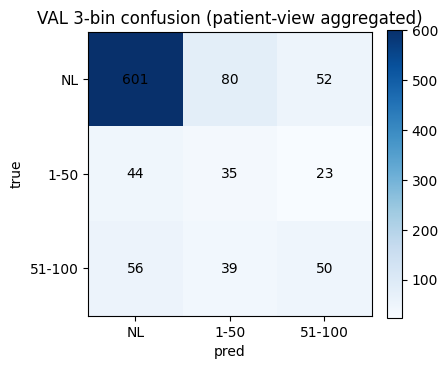

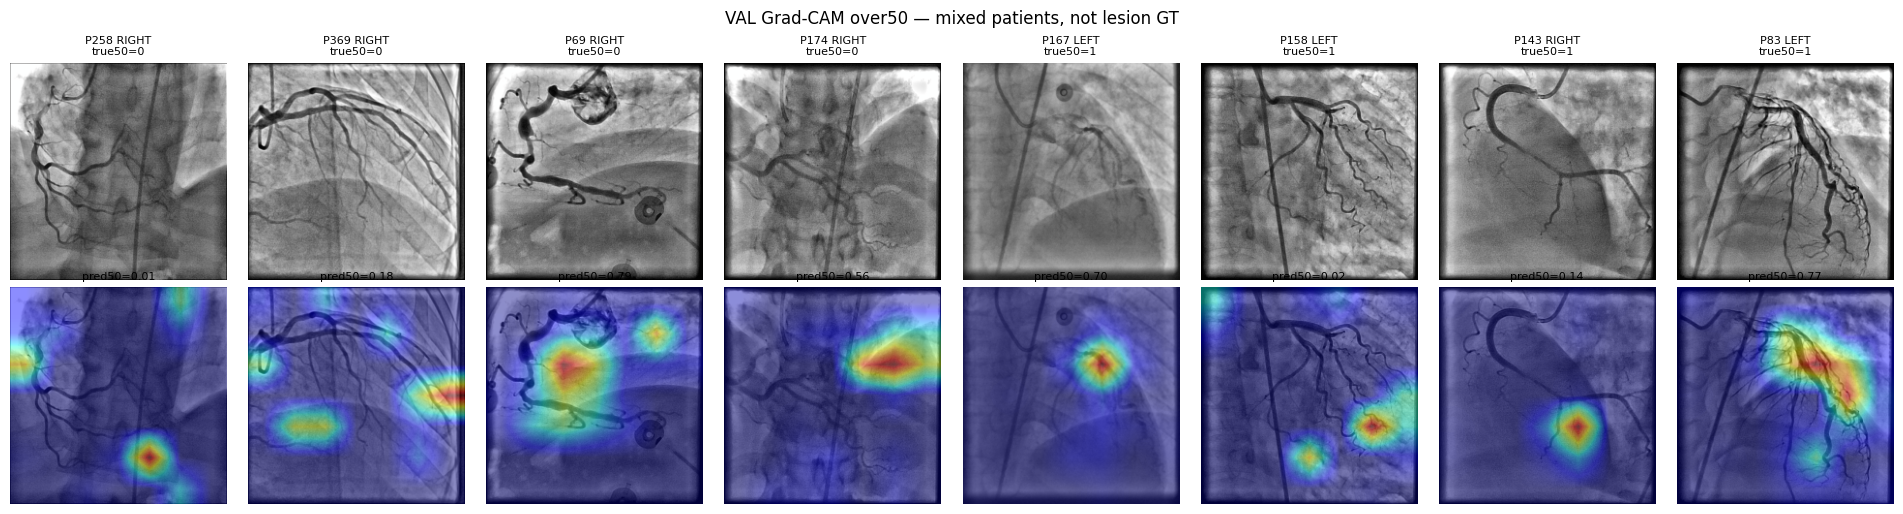

저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/classifier_results/08b_resnet50_3bin_over50
TEST는 아직 실행하지 마세요.


In [14]:
#@title 14. VAL 평가와 Grad-CAM. 같은 환자 8장 금지

ckpt = torch.load(best_path_v2, map_location=DEVICE, weights_only=False)
model_v2.load_state_dict(ckpt["model"])
val_loss, recs = evaluate_v2(val_loader_v2)
val_metrics, val_agg, val_view = metrics_v2(recs, "VAL")
print(json.dumps(val_metrics, indent=2, ensure_ascii=False))

cm = confusion_matrix(val_agg["true"], val_agg["pred"], labels=list(range(NUM_BINS)))
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_BINS), BIN_NAMES)
ax.set_yticks(range(NUM_BINS), BIN_NAMES)
ax.set_xlabel("pred")
ax.set_ylabel("true")
ax.set_title("VAL 3-bin confusion (patient-view aggregated)")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(RESULT_DIR_V2 / "01_val_confusion_3bin.png", dpi=150)
plt.show()

val_agg.to_csv(RESULT_DIR_V2 / "02_val_patient_view_artery.csv", index=False)
with open(RESULT_DIR_V2 / "04_val_metrics.json", "w") as f:
    json.dump(val_metrics, f, indent=2, ensure_ascii=False)


def gradcam_over50(model, image_bchw):
    model.eval()
    acts, grads = [], []

    def fwd(_m, _i, output):
        acts.append(output)

    def bwd(_m, _gi, go):
        grads.append(go[0])

    h1 = model.last_conv().register_forward_hook(fwd)
    h2 = model.last_conv().register_full_backward_hook(bwd)
    model.zero_grad(set_to_none=True)
    _, o_log = model(image_bchw)
    o_log.sum().backward()
    act = acts[0][0].detach()
    grad = grads[0][0].detach()
    w = grad.mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * act).sum(0))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam[None, None], size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)[0, 0].cpu().numpy()
    h1.remove(); h2.remove()
    return cam, float(torch.sigmoid(o_log)[0].detach().cpu())


# 환자별로 1장, true50=0/1을 섞음
val_frame = frame_df.iloc[val_idx].reset_index(drop=True)
groups = defaultdict(list)
for local_i, (_, row) in enumerate(val_frame.iterrows()):
    groups[(int(row["patient_id"]), int(row["over50"]))].append(local_i)

picked = []
neg_keys = [k for k in groups if k[1] == 0]
pos_keys = [k for k in groups if k[1] == 1]
random.Random(SEED).shuffle(neg_keys)
random.Random(SEED).shuffle(pos_keys)
for key in (neg_keys[:4] + pos_keys[:4]):
    picked.append(groups[key][len(groups[key]) // 2])

n_show = len(picked)
fig, axes = plt.subplots(2, n_show, figsize=(2.4 * n_show, 5.2))
for col, local_i in enumerate(picked):
    sample = val_ds_v2[local_i]
    cam, pred50 = gradcam_over50(model_v2, sample["image"][None].to(DEVICE))
    rgb = denorm(sample["image"])
    row = val_frame.iloc[local_i]
    axes[0, col].imshow(rgb); axes[0, col].axis("off")
    axes[0, col].set_title(f"P{int(row['patient_id'])} {row['view']}\ntrue50={int(row['over50'])}", fontsize=8)
    axes[1, col].imshow(rgb); axes[1, col].imshow(cam, cmap="jet", alpha=0.45); axes[1, col].axis("off")
    axes[1, col].set_title(f"pred50={pred50:.2f}", fontsize=8)
fig.suptitle("VAL Grad-CAM over50 — mixed patients, not lesion GT")
fig.tight_layout()
fig.savefig(RESULT_DIR_V2 / "05_val_gradcam_mixed.png", dpi=150)
plt.show()
print("저장:", RESULT_DIR_V2)
print("TEST는 아직 실행하지 마세요.")

# 09. MedicalSAM3 + mLLM controller (36장 파일럿)

## 하는 일
같은 AngioCAD 36장에서 세 조건을 비교한다.
1. 고정 텍스트 `coronary artery` (07 재현)
2. mLLM이 만든 짧은 텍스트만 (음성 대조군)
3. mLLM이 만든 **box**로 MedicalSAM3 분할 (본실험)

mLLM은 mask를 그리지 않는다. JSON으로 혈관명·box만 낸다.
MedicalSAM3는 pretrained inference only. fine-tune 없음.

## 성공 기준 (이번 노트북)
- mLLM box가 혈관 위에 있는가 (사람 채점)
- box mask가 텍스트-only보다 덜 조각/덜 blob인가
- 07의 “GT-box면 회복”이 **모델이 만든 box**에서도 일부 재현되는가

## 하지 않는 것
- 121k 전체, LISA 공동학습, 7등급 분류, TEST 재오픈, 실패한 mask를 UI에 올리기

In [15]:
#@title 01. 마운트, 경로, 필수 파일 확인

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import os
import re
import io
import base64
import hashlib
import random
import shutil
import subprocess
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

VISUAL_DIR = (
    PROJECT_ROOT
    / "dca1_results"
    / "unet128_angiocad_visual_validation"
)

MEDSAM3_WEIGHTS_DIR = (
    PROJECT_ROOT / "external_data" / "MedicalSAM3"
)
MEDSAM3_CHECKPOINT_PATH = MEDSAM3_WEIGHTS_DIR / "checkpoint_2D.pt"

RESULT_DIR = (
    PROJECT_ROOT
    / "dca1_results"
    / "medicalsam3_mllm_controller"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_CSV_CANDIDATES = [
    VISUAL_DIR / "03_angiocad_visual_candidate_frames.csv",
    VISUAL_DIR / "05_angiocad_unet128_candidate_inference.csv",
    VISUAL_DIR / "06_angiocad_unet128_representative_frames.csv",
]

print("Project:", PROJECT_ROOT, PROJECT_ROOT.exists())
print("Visual dir:", VISUAL_DIR.exists())
print("Checkpoint:", MEDSAM3_CHECKPOINT_PATH.exists(), MEDSAM3_CHECKPOINT_PATH)
if MEDSAM3_CHECKPOINT_PATH.exists():
    print("Checkpoint GB:", round(MEDSAM3_CHECKPOINT_PATH.stat().st_size / 1024**3, 2))

for path in CANDIDATE_CSV_CANDIDATES:
    print("CSV:", path.name, path.exists())

assert PROJECT_ROOT.exists(), "PROJECT_ROOT가 없습니다. 6번과 같은 한글 경로로 고치세요."
assert any(p.exists() for p in CANDIDATE_CSV_CANDIDATES), (
    "06번 36장 CSV가 없습니다. "
    "unet128_angiocad_visual_validation 폴더를 확인하세요."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD True
Visual dir: True
Checkpoint: True /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/MedicalSAM3/checkpoint_2D.pt
Checkpoint GB: 9.33
CSV: 03_angiocad_visual_candidate_frames.csv True
CSV: 05_angiocad_unet128_candidate_inference.csv True
CSV: 06_angiocad_unet128_representative_frames.csv True


In [16]:
#@title 02. AngioCAD RAR 재로드 (이미 있으면 건너뜀)

LOCAL_BASE = Path("/content/AngioCAD")
ANGIOCAD_ROOT = LOCAL_BASE / "AngioCAD_Dataset"


def numeric_patient_count(path):
    if not path.is_dir():
        return 0
    return sum(1 for c in path.iterdir() if c.is_dir() and c.name.isdigit())


n_exist = numeric_patient_count(ANGIOCAD_ROOT)
print("기존 환자 폴더:", n_exist)

if n_exist >= 412:
    print("압축 해제 건너뜀")
else:
    rar_parts = [PROJECT_ROOT / f"AngioCAD_Dataset.part{i}.rar" for i in range(1, 5)]
    for p in rar_parts:
        print(p.name, p.exists())
    assert all(p.exists() for p in rar_parts)

    if shutil.which("unrar") is None:
        subprocess.run(["apt-get", "update", "-qq"], check=True)
        subprocess.run(["apt-get", "install", "-y", "unrar"], check=True)

    free_gb = shutil.disk_usage("/content").free / 1024**3
    print("/content 여유 GB:", round(free_gb, 2))
    assert free_gb >= 30

    LOCAL_BASE.mkdir(parents=True, exist_ok=True)
    start = time.time()
    out = subprocess.run(
        ["unrar", "x", "-o+", "-idq", str(rar_parts[0]), str(LOCAL_BASE) + "/"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, errors="replace",
    )
    print("unrar:", out.returncode, "분:", round((time.time() - start) / 60, 2))
    if out.returncode != 0:
        print(out.stdout[-3000:])
    assert out.returncode == 0

    if numeric_patient_count(ANGIOCAD_ROOT) < 412:
        found = [
            p for p in LOCAL_BASE.rglob("AngioCAD_Dataset")
            if p.is_dir() and numeric_patient_count(p) >= 412
        ]
        assert found
        ANGIOCAD_ROOT = found[0]

print("ANGIOCAD_ROOT:", ANGIOCAD_ROOT, numeric_patient_count(ANGIOCAD_ROOT))
assert numeric_patient_count(ANGIOCAD_ROOT) >= 412

기존 환자 폴더: 413
압축 해제 건너뜀
ANGIOCAD_ROOT: /content/AngioCAD/AngioCAD_Dataset 413


In [17]:
#@title 03. 06번 후보 프레임 CSV 로드 및 경로 재생성

csv_path = next(p for p in CANDIDATE_CSV_CANDIDATES if p.exists())
frame_df = pd.read_csv(csv_path)
frame_df.columns = [c.strip() if isinstance(c, str) else c for c in frame_df.columns]
print("사용 CSV:", csv_path.name, "행:", len(frame_df))
print("열:", list(frame_df.columns))

for col in ["patient_id", "series_id"]:
    assert col in frame_df.columns, col
    frame_df[col] = pd.to_numeric(frame_df[col], errors="raise").astype(int)

if "view" in frame_df.columns:
    frame_df["view"] = frame_df["view"].astype(str).str.strip().str.upper()

name_col = "frame_name" if "frame_name" in frame_df.columns else None
if name_col is None:
    for c in frame_df.columns:
        if "frame" in c.lower() and "path" not in c.lower():
            name_col = c
            break
assert name_col is not None, "frame_name 열이 없습니다."

frame_df["resolved_frame_path"] = [
    str(ANGIOCAD_ROOT / str(int(pid)) / str(int(sid)) / str(name))
    for pid, sid, name in zip(
        frame_df["patient_id"], frame_df["series_id"], frame_df[name_col]
    )
]

frame_df["file_exists"] = [Path(p).is_file() for p in frame_df["resolved_frame_path"]]
print("존재:", int(frame_df["file_exists"].sum()), "/", len(frame_df))
assert frame_df["file_exists"].all(), frame_df.loc[~frame_df["file_exists"], "resolved_frame_path"].head()

# 36장이 이상적. 12장 representative만 있으면 그대로 진행하고 표시
print(frame_df[["patient_id", "series_id", "view", name_col]].head())
print("unique series:", frame_df.groupby(["patient_id", "series_id"]).ngroups)
assert len(frame_df) in {12, 36} or len(frame_df) >= 12, len(frame_df)
print("✅ 36장(또는 12장) 재로드 완료")

사용 CSV: 03_angiocad_visual_candidate_frames.csv 행: 36
열: ['patient_id', 'series_id', 'view', 'frame_index', 'frame_name', 'file_path', 'series_frame_count', 'paper_eligible', 'extended_eligible', 'max_segment', 'max_grade_index', 'max_grade_label', 'severity_group', 'sample_position', 'resolved_frame_path', 'file_exists']
존재: 36 / 36
   patient_id  series_id   view      frame_name
0          32          7  RIGHT  frame_0000.png
1          32          7  RIGHT  frame_0028.png
2          32          7  RIGHT  frame_0055.png
3          33          1   LEFT  frame_0000.png
4          33          1   LEFT  frame_0019.png
unique series: 12
✅ 36장(또는 12장) 재로드 완료


In [18]:
#@title 04. Medical-SAM3 clone 및 설치. numpy 에러 나면 런타임 재시작

REPO_DIR = Path("/content/Medical-SAM3")
REPO_URL = "https://github.com/AIM-Research-Lab/Medical-SAM3.git"
PINNED_COMMIT = "4164d261b5a8c9fc1015a2e21537280a19c972c5"

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

subprocess.run(["git", "clone", "--recursive", REPO_URL, str(REPO_DIR)], check=True)
subprocess.run(["git", "-C", str(REPO_DIR), "checkout", PINNED_COMMIT], check=False)

commit = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print("commit:", commit)

# 공식 pyproject의 numpy==1.26 은 PyPI에 없음 → --no-deps
subprocess.run(
    ["pip", "install", "-e", str(REPO_DIR), "--no-deps"],
    check=True,
)
subprocess.run(
    [
        "pip", "install",
        "numpy==1.26.4",
        "pillow",
        "opencv-python-headless",
        "scikit-image",
        "matplotlib",
        "pandas",
        "huggingface_hub",
        "openai",
    ],
    check=True,
)

print("설치 끝. 아래 ImportError가 나면 런타임 재시작 후 셀 1→2→3→5부터.")

commit: 4164d261b5a8c9fc1015a2e21537280a19c972c5
설치 끝. 아래 ImportError가 나면 런타임 재시작 후 셀 1→2→3→5부터.


In [20]:
#@title 05. checkpoint 확인/다운로드, 모델 로드, 스모크

import sys
import torch

#@title 04b. Medical-SAM3 기본 의존성 (numpy 핀은 건드리지 않음)

import subprocess

subprocess.run(
    [
        "pip", "install",
        "iopath>=0.1.10",
        "timm>=1.0.17",
        "tqdm",
        "ftfy==6.1.1",
        "regex",
        "typing_extensions",
        "huggingface_hub",
    ],
    check=True,
)

print("설치 완료. 셀 5를 다시 실행하세요.")

EXPECTED_SHA = "f7fb9f207d587e95bcb23fb9324979db583045b71488278940c0d170bf1516fd"
HF_REPO = "ChongCong/Medical-SAM3"

MEDSAM3_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

if not MEDSAM3_CHECKPOINT_PATH.exists():
    print("Drive에 checkpoint 없음. HF에서 받습니다. 약 9GB.")
    from huggingface_hub import hf_hub_download
    downloaded = hf_hub_download(
        repo_id=HF_REPO,
        filename="checkpoint_2D.pt",
        local_dir=str(MEDSAM3_WEIGHTS_DIR),
    )
    print("다운로드:", downloaded)

def sha256_file(path, chunk=1 << 24):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

print("checkpoint GB:", round(MEDSAM3_CHECKPOINT_PATH.stat().st_size / 1024**3, 2))
digest = sha256_file(MEDSAM3_CHECKPOINT_PATH)
print("sha256:", digest)
if digest != EXPECTED_SHA:
    print("경고: 07에서 기록한 SHA와 다릅니다. 일단 진행은 합니다.")

assert torch.cuda.is_available(), "GPU 런타임으로 바꾸세요."
print("GPU:", torch.cuda.get_device_name(0))

REPO_DIR = Path("/content/Medical-SAM3")
assert REPO_DIR.exists(), "셀 4 clone이 필요합니다."

sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(REPO_DIR / "inference"))
sys.path.insert(0, str(REPO_DIR / "sam3"))

import inference.sam3_inference as sam3_inf
sam3_inf.SAM3_ROOT = REPO_DIR  # 업스트림 NameError 패치
from inference.sam3_inference import SAM3Model, resize_mask

OFFICIAL_TEXT = "coronary artery"
CONF_TH = 0.1

medsam3 = SAM3Model(
    confidence_threshold=CONF_TH,
    device="cuda",
    checkpoint_path=str(MEDSAM3_CHECKPOINT_PATH),
)
t0 = time.time()
medsam3.load_model()
print("load 초:", round(time.time() - t0, 1))
print("peak GB:", round(torch.cuda.max_memory_allocated() / 1024**3, 2))

dummy = np.full((512, 512, 3), 40, dtype=np.uint8)
state = medsam3.encode_image(dummy)
smoke = medsam3.predict_text(state, OFFICIAL_TEXT)
print("smoke mask:", None if smoke is None else smoke.shape, "sum:", 0 if smoke is None else int(smoke.sum()))
print("✅ MedicalSAM3 재로드")

설치 완료. 셀 5를 다시 실행하세요.
checkpoint GB: 9.33
sha256: f7fb9f207d587e95bcb23fb9324979db583045b71488278940c0d170bf1516fd
GPU: NVIDIA L4


Exception ignored on calling ctypes callback function <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c5844498f40>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.13/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/usr/local/lib/python3.13/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib/python3.13/ctypes/__init__.py", line 361, in __init__
    self._handle = self._load_library(name, mode, handle, winmode)
  File "/usr/lib/python3.13/ctypes/__init__.py", line 403, in _load_library
    return _dlopen(name, mode)
OSError: /usr/local/lib/python3.13/dist-packages/numpy.libs/libscipy_openblas64_-ff651d7f.so: cannot 

Loading SAM3 model from checkpoint: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/MedicalSAM3/checkpoint_2D.pt
Loading custom checkpoint: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/MedicalSAM3/checkpoint_2D.pt
SAM3 model loaded successfully!
load 초: 19.6
peak GB: 4.0
smoke mask: None sum: 0
✅ MedicalSAM3 재로드


In [21]:
#@title 06. 36장 고정 텍스트 coronary artery

ALLOWED_TEXT = {
    "coronary artery",
    "left coronary artery",
    "right coronary artery",
    "left anterior descending coronary artery",
    "left circumflex coronary artery",
    "left main coronary artery",
    "right coronary artery tree",
}


def read_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    assert bgr is not None, path
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def squeeze_mask(mask, hw):
    if mask is None:
        return None
    mask = np.squeeze(mask)
    if mask.ndim != 2:
        mask = mask[0]
    if mask.shape != hw:
        mask = resize_mask(mask.astype(np.uint8), hw)
    return (mask > 0).astype(np.uint8)


text_rows = []
text_masks = []

for i, row in frame_df.iterrows():
    rgb = read_rgb(row["resolved_frame_path"])
    h, w = rgb.shape[:2]
    state = medsam3.encode_image(rgb)
    mask = squeeze_mask(medsam3.predict_text(state, OFFICIAL_TEXT), (h, w))
    detected = mask is not None and mask.sum() > 0
    text_masks.append(mask if detected else np.zeros((h, w), np.uint8))
    text_rows.append({
        "row_index": int(i),
        "patient_id": int(row["patient_id"]),
        "series_id": int(row["series_id"]),
        "view": row.get("view", ""),
        "frame_name": str(row[name_col]),
        "condition": "text_official",
        "prompt": OFFICIAL_TEXT,
        "detected": bool(detected),
        "area_ratio": float(text_masks[-1].mean()),
        "h": h, "w": w,
    })
    print(i, row["patient_id"], row.get("view", ""), "det", detected, "area", round(text_rows[-1]["area_ratio"], 4))

text_df = pd.DataFrame(text_rows)
text_df.to_csv(RESULT_DIR / "01_text_official_36.csv", index=False)
print("탐지율:", float(text_df["detected"].mean()))
print("평균 area:", float(text_df["area_ratio"].mean()))

0 32 RIGHT det True area 0.0076
1 32 RIGHT det True area 0.0042
2 32 RIGHT det True area 0.0074
3 33 LEFT det True area 0.0058
4 33 LEFT det True area 0.006
5 33 LEFT det True area 0.0069
6 55 LEFT det True area 0.0047
7 55 LEFT det True area 0.0077
8 55 LEFT det True area 0.0039
9 140 RIGHT det True area 0.0394
10 140 RIGHT det True area 0.0155
11 140 RIGHT det True area 0.0062
12 147 LEFT det True area 0.0028
13 147 LEFT det True area 0.0103
14 147 LEFT det True area 0.0037
15 266 RIGHT det True area 0.0072
16 266 RIGHT det True area 0.0047
17 266 RIGHT det True area 0.0036
18 267 RIGHT det False area 0.0
19 267 RIGHT det True area 0.0078
20 267 RIGHT det True area 0.0075
21 308 LEFT det True area 0.0218
22 308 LEFT det True area 0.0044
23 308 LEFT det True area 0.0066
24 315 RIGHT det True area 0.0113
25 315 RIGHT det True area 0.0058
26 315 RIGHT det True area 0.0043
27 357 LEFT det True area 0.004
28 357 LEFT det True area 0.0085
29 357 LEFT det True area 0.0108
30 357 RIGHT det T

In [23]:
#@title 07. GPT-4o가 box JSON 생성. mask는 만들지 않음

from google.colab import userdata
from openai import OpenAI

try:
    OPENAI_API_KEY = userdata.get("SAM3")
except Exception:
    OPENAI_API_KEY = os.environ.get("SAM3")

assert OPENAI_API_KEY, (
    "왼쪽 열쇠 아이콘 → 비밀값 이름 OPENAI_API_KEY 로 키를 넣으세요."
)

client = OpenAI(api_key=OPENAI_API_KEY)
MLLM_MODEL = "gpt-4o"

SYSTEM = """You are a controller for Medical SAM3 on X-ray coronary angiography.
You never output a pixel mask.
You only output one JSON object.

Rules:
- Coordinates are NORMALIZED to [0,1] as [x0, y0, x1, y1] in the original image.
- The box must tightly cover the main coronary vessel tree of the requested view, not the whole frame, not the catheter hub only.
- sam_text MUST be one of:
  coronary artery
  left coronary artery
  right coronary artery
  left anterior descending coronary artery
  left circumflex coronary artery
  left main coronary artery
- If unsure, still give your best box and set confidence low.
- No markdown, no extra keys.
"""


def encode_jpeg(rgb, max_side=1024):
    h, w = rgb.shape[:2]
    scale = min(1.0, max_side / max(h, w))
    if scale < 1:
        rgb = cv2.resize(rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    ok, buf = cv2.imencode(".jpg", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), 85])
    assert ok
    return base64.b64encode(buf.tobytes()).decode("ascii")


def default_vessel(row):
    view = str(row.get("view", "")).upper()
    seg = str(row.get("max_segment", "") or row.get("target_vessel", "") or "")
    if "RCA" in seg.upper() or view == "RIGHT":
        return "RCA", "right coronary artery"
    if "LCX" in seg.upper():
        return "LCX", "left circumflex coronary artery"
    if "LAD" in seg.upper():
        return "LAD", "left anterior descending coronary artery"
    if view == "LEFT":
        return "LCA", "left coronary artery"
    return "coronary", "coronary artery"


def ask_mllm(rgb, row):
    target, default_text = default_vessel(row)
    user_text = (
        f"View metadata: {row.get('view', 'UNKNOWN')}. "
        f"Please localize {target} in this angiogram. "
        "Return JSON with keys: "
        "target_vessel, sam_text, box_xyxy_norm, positive_points_norm, confidence, notes."
    )
    resp = client.chat.completions.create(
        model=MLLM_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": SYSTEM},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_text},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": "data:image/jpeg;base64," + encode_jpeg(rgb),
                            "detail": "high",
                        },
                    },
                ],
            },
        ],
    )
    raw = resp.choices[0].message.content
    data = json.loads(raw)
    data["_raw"] = raw
    data["_default_text"] = default_text
    data["_target"] = target
    return data


def clamp01(v):
    return float(min(1.0, max(0.0, float(v))))


def parse_box(data, w, h):
    box = data.get("box_xyxy_norm") or data.get("box") or data.get("bbox")
    if not box or len(box) != 4:
        return None
    x0, y0, x1, y1 = [clamp01(v) for v in box]
    if x1 <= x0:
        x0, x1 = x1, x0
    if y1 <= y0:
        y0, y1 = y1, y0
    # 전체 화면/점 박스는 무효
    area = (x1 - x0) * (y1 - y0)
    if area < 0.01 or area > 0.95:
        return None
    return (
        int(round(x0 * w)),
        int(round(y0 * h)),
        int(round(x1 * w)),
        int(round(y1 * h)),
    )


def sanitize_text(data):
    text = str(data.get("sam_text") or data.get("_default_text") or OFFICIAL_TEXT).strip().lower()
    if text not in ALLOWED_TEXT:
        text = data.get("_default_text", OFFICIAL_TEXT)
    return text


mllm_rows = []
for i, row in frame_df.iterrows():
    rgb = read_rgb(row["resolved_frame_path"])
    h, w = rgb.shape[:2]
    try:
        data = ask_mllm(rgb, row)
        err = ""
    except Exception as e:
        data = {"_default_text": default_vessel(row)[1]}
        err = str(e)

    box = parse_box(data, w, h) if not err else None
    text = sanitize_text(data)
    mllm_rows.append({
        "row_index": int(i),
        "patient_id": int(row["patient_id"]),
        "series_id": int(row["series_id"]),
        "view": row.get("view", ""),
        "h": h, "w": w,
        "target_vessel": data.get("target_vessel") or data.get("_target"),
        "sam_text": text,
        "box_x0": None if box is None else box[0],
        "box_y0": None if box is None else box[1],
        "box_x1": None if box is None else box[2],
        "box_y1": None if box is None else box[3],
        "box_valid": box is not None,
        "confidence": data.get("confidence"),
        "notes": data.get("notes", ""),
        "raw_json": data.get("_raw", ""),
        "error": err,
    })
    print(i, row["patient_id"], "box", box, "text", text, err)

mllm_df = pd.DataFrame(mllm_rows)
mllm_df.to_csv(RESULT_DIR / "02_mllm_prompts_36.csv", index=False)
print("유효 box 비율:", float(mllm_df["box_valid"].mean()))
print("저장:", RESULT_DIR / "02_mllm_prompts_36.csv")

0 32 box (154, 154, 358, 358) text right coronary artery 
1 32 box (128, 154, 384, 358) text right coronary artery 
2 32 box (154, 205, 358, 410) text right coronary artery 
3 33 box (128, 128, 384, 384) text left coronary artery 
4 33 box (77, 77, 435, 384) text left coronary artery 
5 33 box (77, 128, 384, 333) text left coronary artery 
6 55 box (128, 154, 384, 358) text left coronary artery 
7 55 box (102, 102, 410, 410) text left coronary artery 
8 55 box (102, 154, 410, 358) text left coronary artery 
9 140 box (154, 154, 358, 358) text right coronary artery 
10 140 box (102, 154, 410, 358) text right coronary artery 
11 140 box (205, 154, 358, 307) text right coronary artery 
12 147 box (154, 154, 358, 358) text left anterior descending coronary artery 
13 147 box (154, 154, 358, 358) text left anterior descending coronary artery 
14 147 box (154, 154, 358, 358) text left anterior descending coronary artery 
15 266 box (154, 154, 358, 358) text right coronary artery 
16 266 box 

In [24]:
#@title 08. MedicalSAM3: mLLM 텍스트 vs mLLM box

box_masks = []
mllm_text_masks = []
cmp_rows = []

for i, row in frame_df.iterrows():
    prompt = mllm_df.loc[mllm_df["row_index"].eq(i)].iloc[0]
    rgb = read_rgb(row["resolved_frame_path"])
    h, w = rgb.shape[:2]
    state = medsam3.encode_image(rgb)

    tmask = squeeze_mask(medsam3.predict_text(state, prompt["sam_text"]), (h, w))
    tdet = tmask is not None and tmask.sum() > 0
    tmask = tmask if tdet else np.zeros((h, w), np.uint8)
    mllm_text_masks.append(tmask)

    bmask = None
    bdet = False
    if bool(prompt["box_valid"]):
        bbox = (
            int(prompt["box_x0"]), int(prompt["box_y0"]),
            int(prompt["box_x1"]), int(prompt["box_y1"]),
        )
        state = medsam3.encode_image(rgb)
        bmask = squeeze_mask(medsam3.predict_box(state, bbox, (h, w)), (h, w))
        bdet = bmask is not None and bmask.sum() > 0
    bmask = bmask if bdet else np.zeros((h, w), np.uint8)
    box_masks.append(bmask)

    inter = np.logical_and(text_masks[i] > 0, bmask > 0).sum()
    union = np.logical_or(text_masks[i] > 0, bmask > 0).sum()
    iou = float(inter / union) if union else 0.0

    cmp_rows.append({
        "row_index": int(i),
        "patient_id": int(row["patient_id"]),
        "series_id": int(row["series_id"]),
        "view": row.get("view", ""),
        "text_official_detected": bool(text_df.loc[i, "detected"]),
        "text_official_area": float(text_df.loc[i, "area_ratio"]),
        "mllm_text": prompt["sam_text"],
        "mllm_text_detected": bool(tdet),
        "mllm_text_area": float(tmask.mean()),
        "mllm_box_valid": bool(prompt["box_valid"]),
        "mllm_box_detected": bool(bdet),
        "mllm_box_area": float(bmask.mean()),
        "official_vs_box_iou": iou,
        "box_xyxy": None if not prompt["box_valid"] else [
            int(prompt["box_x0"]), int(prompt["box_y0"]),
            int(prompt["box_x1"]), int(prompt["box_y1"]),
        ],
        "vessel_hit_0_to_2": "",
        "box_on_vessel": "",
        "box_better_than_text": "",
        "reviewer_note": "",
    })
    print(
        i, "off", int(text_df.loc[i, "detected"]),
        "mtext", int(tdet), "mbox", int(bdet),
        "iou", round(iou, 3),
    )

cmp_df = pd.DataFrame(cmp_rows)
cmp_df.to_csv(RESULT_DIR / "03_compare_text_vs_mllmbox.csv", index=False)
print(cmp_df[["text_official_detected", "mllm_text_detected", "mllm_box_detected", "mllm_box_valid"]].mean())

0 off 1 mtext 1 mbox 1 iou 0.0
1 off 1 mtext 1 mbox 1 iou 0.0
2 off 1 mtext 1 mbox 1 iou 0.0
3 off 1 mtext 1 mbox 1 iou 0.0
4 off 1 mtext 1 mbox 1 iou 0.143
5 off 1 mtext 1 mbox 1 iou 0.447
6 off 1 mtext 1 mbox 1 iou 0.0
7 off 1 mtext 1 mbox 1 iou 0.206
8 off 1 mtext 1 mbox 1 iou 0.0
9 off 1 mtext 1 mbox 1 iou 0.144
10 off 1 mtext 1 mbox 1 iou 0.012
11 off 1 mtext 1 mbox 1 iou 0.0
12 off 1 mtext 1 mbox 1 iou 0.0
13 off 1 mtext 1 mbox 1 iou 0.626
14 off 1 mtext 1 mbox 1 iou 0.0
15 off 1 mtext 1 mbox 1 iou 0.02
16 off 1 mtext 1 mbox 1 iou 0.0
17 off 1 mtext 1 mbox 1 iou 0.0
18 off 0 mtext 1 mbox 1 iou 0.0
19 off 1 mtext 1 mbox 1 iou 0.656
20 off 1 mtext 1 mbox 1 iou 0.0
21 off 1 mtext 1 mbox 1 iou 0.019
22 off 1 mtext 1 mbox 1 iou 0.407
23 off 1 mtext 1 mbox 1 iou 0.0
24 off 1 mtext 1 mbox 1 iou 0.0
25 off 1 mtext 1 mbox 1 iou 0.259
26 off 1 mtext 1 mbox 1 iou 0.0
27 off 1 mtext 1 mbox 1 iou 0.0
28 off 1 mtext 1 mbox 1 iou 0.0
29 off 1 mtext 1 mbox 1 iou 0.0
30 off 1 mtext 1 mbox 1 iou 0

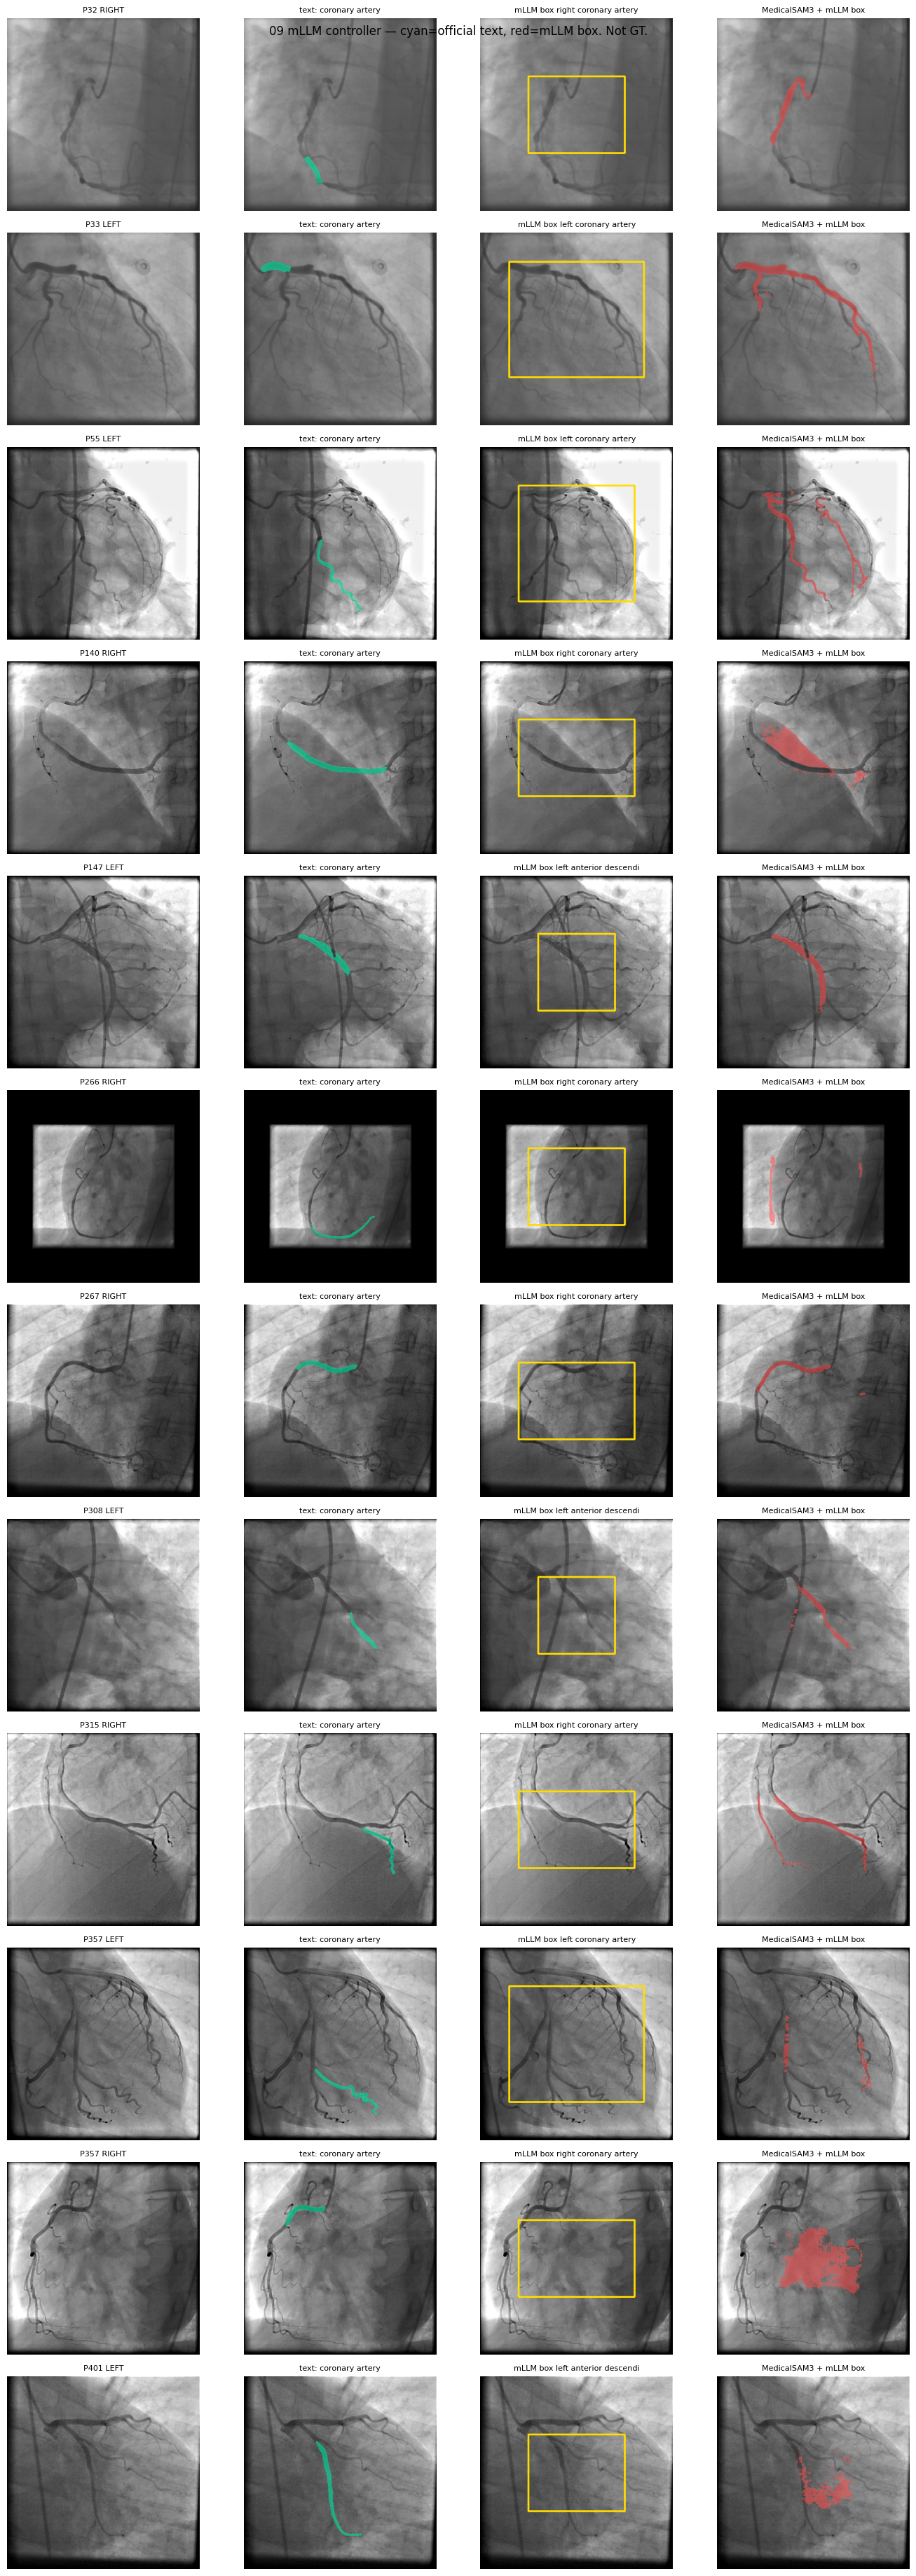

{
  "notebook": "09_AngioCAD_MedicalSAM3_mLLM_Controller",
  "n_frames": 36,
  "official_text": "coronary artery",
  "mllm_model": "gpt-4o",
  "text_official_detect_rate": 0.9722222222222222,
  "mllm_box_valid_rate": 1.0,
  "mllm_box_detect_rate": 1.0,
  "mean_official_vs_box_iou": 0.0874116613976451,
  "note": "No pixel GT on AngioCAD. Human review columns in 03_compare_text_vs_mllmbox.csv are still empty.",
  "do_not": "Do not put these masks in the UI. Do not run 08 TEST."
}
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/medicalsam3_mllm_controller


In [25]:
#@title 09. 시각 비교. 사람 채점용

n_show = min(12, len(frame_df))
# series가 여러 장이면 중간 것만
show_idx = list(frame_df.index[:n_show])
if "sample_position" in frame_df.columns:
    mid = frame_df.index[frame_df["sample_position"].astype(str).eq("MIDDLE")]
    if len(mid) >= 8:
        show_idx = list(mid[:12])

fig, axes = plt.subplots(len(show_idx), 4, figsize=(14, 3.1 * len(show_idx)))
if len(show_idx) == 1:
    axes = np.array(axes).reshape(1, 4)

for r, i in enumerate(show_idx):
    row = frame_df.loc[i]
    rgb = read_rgb(row["resolved_frame_path"])
    prompt = mllm_df.loc[mllm_df["row_index"].eq(i)].iloc[0]
    tmask = text_masks[i]
    bmask = box_masks[i]

    overlay_t = rgb.copy()
    overlay_t[tmask > 0] = (
        0.45 * overlay_t[tmask > 0] + np.array([0, 255, 180]) * 0.55
    ).astype(np.uint8)
    overlay_b = rgb.copy()
    overlay_b[bmask > 0] = (
        0.45 * overlay_b[bmask > 0] + np.array([255, 80, 80]) * 0.55
    ).astype(np.uint8)

    boxed = rgb.copy()
    if bool(prompt["box_valid"]):
        cv2.rectangle(
            boxed,
            (int(prompt["box_x0"]), int(prompt["box_y0"])),
            (int(prompt["box_x1"]), int(prompt["box_y1"])),
            (255, 220, 0), 3,
        )

    axes[r, 0].imshow(rgb)
    axes[r, 0].set_title(f"P{int(row['patient_id'])} {row.get('view','')}", fontsize=8)
    axes[r, 1].imshow(overlay_t)
    axes[r, 1].set_title("text: coronary artery", fontsize=8)
    axes[r, 2].imshow(boxed)
    axes[r, 2].set_title(f"mLLM box {prompt['sam_text'][:22]}", fontsize=8)
    axes[r, 3].imshow(overlay_b)
    axes[r, 3].set_title("MedicalSAM3 + mLLM box", fontsize=8)
    for c in range(4):
        axes[r, c].axis("off")

fig.suptitle("09 mLLM controller — cyan=official text, red=mLLM box. Not GT.")
fig.tight_layout()
fig.savefig(RESULT_DIR / "04_overlay_text_vs_mllmbox.png", dpi=140)
plt.show()

np.savez_compressed(
    RESULT_DIR / "05_masks_36.npz",
    text_official=np.array(text_masks, dtype=object),
    mllm_text=np.array(mllm_text_masks, dtype=object),
    mllm_box=np.array(box_masks, dtype=object),
)

decision = {
    "notebook": "09_AngioCAD_MedicalSAM3_mLLM_Controller",
    "n_frames": int(len(frame_df)),
    "official_text": OFFICIAL_TEXT,
    "mllm_model": MLLM_MODEL,
    "text_official_detect_rate": float(text_df["detected"].mean()),
    "mllm_box_valid_rate": float(mllm_df["box_valid"].mean()),
    "mllm_box_detect_rate": float(cmp_df["mllm_box_detected"].mean()),
    "mean_official_vs_box_iou": float(cmp_df["official_vs_box_iou"].mean()),
    "note": "No pixel GT on AngioCAD. Human review columns in 03_compare_text_vs_mllmbox.csv are still empty.",
    "do_not": "Do not put these masks in the UI. Do not run 08 TEST.",
}
with open(RESULT_DIR / "06_pilot_summary.json", "w") as f:
    json.dump(decision, f, indent=2, ensure_ascii=False)
print(json.dumps(decision, indent=2, ensure_ascii=False))
print("저장:", RESULT_DIR)